# Optuna SQLite Viewer

`optuna_jh.db`의 모든 study와 trial을 DataFrame으로 로드한다.

In [1]:
import os, sys

try:
    import google.colab
    if not os.path.exists("/content/project/setup.py"):
        os.system("pip install -q gdown")
        os.system("gdown --id 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip")
        os.system("unzip -qo /content/code.zip -d /content/project")
        os.makedirs("/content/project/0_data", exist_ok=True)
        os.system("gdown --id 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip")
        os.system("unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data")
        os.remove("/content/project/0_data/dataset.zip")
    sys.path.insert(0, "/content/project")
    %run /content/project/setup.py
except ImportError:
    %run ../../setup.py

setup 완료


In [2]:
import optuna
import pandas as pd
from pathlib import Path

optuna.logging.set_verbosity(optuna.logging.WARNING)

DB_PATH = Path("optuna_merged.db").resolve()
STORAGE = f"sqlite:///{DB_PATH.as_posix()}"
print(f"DB: {DB_PATH}")

summaries = optuna.get_all_study_summaries(STORAGE)
study_info = pd.DataFrame([
    {
        "study_name": s.study_name,
        "n_trials": s.n_trials,
        "direction": s.direction.name,
        "best_value": s.best_trial.value if s.best_trial else None,
        "datetime_start": s.datetime_start,
    }
    for s in summaries
])
study_info

DB: C:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\optuna_merged.db


,study_name,n_trials,direction,best_value,datetime_start
0,3-101-001,440,MINIMIZE,0.005544,2026-04-13 16:54:40.233101
1,3-101-002,53,MINIMIZE,0.005528,2026-04-14 09:50:01.681912
2,1-002-002,15,MINIMIZE,0.005501,2026-04-13 14:14:59.752422
3,1-002-001,5,MINIMIZE,0.005502,2026-04-13 14:54:43.001883
4,1-003-001,10,MINIMIZE,0.001387,2026-04-13 16:45:33.578429
5,1-010-001,480,MINIMIZE,0.001315,2026-04-13 16:54:14.506800
6,1-010-002,67,MINIMIZE,0.001387,2026-04-14 09:48:49.916675
7,1-100-001,400,MINIMIZE,0.005456,2026-04-13 20:37:21.492065
8,1-100-002,87,MINIMIZE,0.005994,2026-04-14 09:48:44.335686


In [3]:
# 모든 study의 trial을 하나의 DataFrame으로 합치기
frames = []
for s in summaries:
    study = optuna.load_study(study_name=s.study_name, storage=STORAGE)
    df = study.trials_dataframe()
    df.insert(0, "study_name", s.study_name)
    frames.append(df)

trials_df = pd.concat(frames, ignore_index=True)
print(f"shape: {trials_df.shape}")
trials_df.head()

shape: (1557, 64)


,study_name,number,value,datetime_start,datetime_complete,duration,params_clf_colsample_bytree,params_clf_filter_threshold,params_clf_learning_rate,params_clf_max_depth,...,user_attrs_clf_val_recall,user_attrs_n_feat_clean,user_attrs_n_feat_selected,user_attrs_outlier_args,user_attrs_saved_at,user_attrs_selected_cols,user_attrs_train_rmse,user_attrs_val_rmse,system_attrs_fixed_params,state
0,3-101-001,0,0.006123,2026-04-13 16:54:40.233101,2026-04-13 16:55:33.532639,0 days 00:00:53.299538,0.738578,0.25,0.018649,12.0,...,0.0,569.0,570.0,"{'method': 'winsorize', 'lower_pct': 0.0, 'upp...",2026-04-13 16:55,"[X4, X6, X7, X10, X12, X14, X17, X18, X19, X21...",0.006123,0.006331,NaN,COMPLETE
1,3-101-001,1,0.006123,2026-04-13 16:55:33.690055,2026-04-13 16:56:24.209119,0 days 00:00:50.519064,0.826914,0.50,0.021792,9.0,...,0.0,667.0,668.0,"{'method': 'winsorize', 'lower_pct': 0.0, 'upp...",2026-04-13 16:56,"[X4, X5, X6, X7, X8, X9, X10, X11, X12, X13, X...",0.006123,0.006331,NaN,COMPLETE
2,3-101-001,2,0.006123,2026-04-13 16:56:24.355518,2026-04-13 16:57:20.541679,0 days 00:00:56.186161,0.853378,0.45,0.014115,11.0,...,0.0,663.0,664.0,"{'method': 'winsorize', 'lower_pct': 0.0, 'upp...",2026-04-13 16:57,"[X4, X5, X6, X7, X8, X9, X10, X11, X12, X13, X...",0.006123,0.006331,NaN,COMPLETE
3,3-101-001,3,0.005873,2026-04-13 16:57:20.686870,2026-04-13 16:58:43.653218,0 days 00:01:22.966348,0.848614,0.10,0.020429,9.0,...,0.0,569.0,570.0,"{'method': 'winsorize', 'lower_pct': 0.0, 'upp...",2026-04-13 16:58,"[X4, X6, X7, X10, X12, X14, X17, X18, X19, X21...",0.005873,0.006085,NaN,COMPLETE
4,3-101-001,4,0.006123,2026-04-13 16:58:43.803573,2026-04-13 17:00:05.002732,0 days 00:01:21.199159,0.880904,0.10,0.020039,9.0,...,0.0,671.0,672.0,"{'method': 'winsorize', 'lower_pct': 0.0, 'upp...",2026-04-13 17:00,"[X1, X4, X5, X6, X7, X8, X9, X10, X11, X12, X1...",0.006123,0.006331,NaN,COMPLETE


## 1. 성능순 정렬 (Top-N)

분석할 study를 고르고 objective 값 기준으로 정렬한다.

In [4]:
# 분석 대상 study 선택 (None이면 trial 수가 가장 많은 study)
TARGET_STUDY = "3-101-001"
TOP_N = 20

if TARGET_STUDY is None:
    TARGET_STUDY = study_info.sort_values("n_trials", ascending=False).iloc[0]["study_name"]
print(f"target study: {TARGET_STUDY}")

direction = next(s.direction.name for s in summaries if s.study_name == TARGET_STUDY)
ascending = (direction == "MINIMIZE")

sub = trials_df[(trials_df["study_name"] == TARGET_STUDY) & (trials_df["state"] == "COMPLETE")].copy()
sub_sorted = sub.sort_values("value", ascending=ascending).reset_index(drop=True)

param_cols = [c for c in sub_sorted.columns if c.startswith("params_")]
show_cols = ["number", "value"] + param_cols
print(f"COMPLETE trials: {len(sub_sorted)} | direction: {direction} | params: {len(param_cols)}")
sub_sorted[show_cols].head(TOP_N)

target study: 3-101-001
COMPLETE trials: 439 | direction: MINIMIZE | params: 41


,number,value,params_clf_colsample_bytree,params_clf_filter_threshold,params_clf_learning_rate,params_clf_max_depth,params_clf_min_child_samples,params_clf_min_split_gain,params_clf_n_estimators,params_clf_num_leaves,...,params_reg_max_depth,params_reg_min_child_samples,params_reg_min_split_gain,params_reg_n_estimators,params_reg_num_leaves,params_reg_path_smooth,params_reg_reg_alpha,params_reg_reg_lambda,params_reg_subsample,params_zero_clip_threshold
0,439,0.005544,0.743572,0.5,0.008029,10.0,10.0,0.008004,2215.0,289.0,...,10.0,68.0,1.058833e-07,1232.0,107.0,2.243304,1.798714,2.646255e-07,0.863086,0.002
1,335,0.005545,0.769344,0.5,0.009471,10.0,15.0,0.012383,2591.0,268.0,...,12.0,34.0,3.606381e-08,1282.0,127.0,3.417314,1.581782,8.094766e-07,0.780331,0.002
2,358,0.005545,0.765709,0.5,0.008804,10.0,12.0,0.011536,2535.0,275.0,...,12.0,43.0,1.443101e-08,1309.0,113.0,5.147316,0.708068,2.545556e-07,0.849853,0.002
3,366,0.005545,0.765399,0.5,0.009390,10.0,10.0,0.008939,2526.0,282.0,...,11.0,70.0,3.405272e-08,1290.0,123.0,2.588358,0.600321,2.538803e-07,0.850326,0.002
4,419,0.005545,0.742688,0.5,0.008417,10.0,10.0,0.005378,2344.0,255.0,...,10.0,66.0,6.465647e-08,1237.0,86.0,2.935070,2.381677,1.074393e-07,0.851207,0.002
5,353,0.005545,0.776603,0.5,0.009563,10.0,13.0,0.013588,2530.0,266.0,...,11.0,47.0,3.187866e-08,1294.0,115.0,4.091445,1.117278,3.134778e-07,0.875082,0.002
6,421,0.005545,0.737683,0.5,0.008229,10.0,9.0,0.005207,2404.0,253.0,...,10.0,76.0,6.798270e-08,501.0,87.0,1.098937,2.578090,1.767996e-07,0.850707,0.002
7,420,0.005545,0.741643,0.5,0.008368,10.0,10.0,0.005436,2399.0,254.0,...,10.0,68.0,5.328456e-08,667.0,85.0,1.522838,2.432654,1.401352e-07,0.850822,0.002
8,332,0.005545,0.758481,0.5,0.009651,10.0,13.0,0.011747,2628.0,260.0,...,12.0,26.0,1.967876e-08,1325.0,125.0,3.801376,1.923722,7.666303e-07,0.783599,0.002
9,415,0.005545,0.739708,0.5,0.008014,10.0,12.0,0.006828,2360.0,257.0,...,10.0,78.0,9.170918e-08,1245.0,96.0,2.865187,2.866992,1.687950e-07,0.856161,0.002


## 2. 파라미터 중요도 (fANOVA)

Optuna 내장 importance로 objective에 가장 큰 영향을 준 파라미터를 뽑는다.

In [5]:
from optuna.importance import get_param_importances, FanovaImportanceEvaluator

study = optuna.load_study(study_name=TARGET_STUDY, storage=STORAGE)
importances = get_param_importances(study, evaluator=FanovaImportanceEvaluator(seed=42))
importance_df = (
    pd.DataFrame({"param": list(importances.keys()), "importance": list(importances.values())})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
importance_df

,param,importance
0,zero_clip_threshold,9.910781e-01
1,clf_filter_threshold,5.159295e-03
2,clf_max_depth,7.275462e-04
3,clf_min_child_samples,5.536685e-04
4,clf_path_smooth,5.385432e-04
5,reg_colsample_bytree,3.535712e-04
6,clf_subsample,2.455849e-04
7,reg_n_estimators,2.254991e-04
8,clf_colsample_bytree,2.254983e-04
9,clf_learning_rate,2.037352e-04


## 3. 상위 trial의 파라미터 분포

objective 기준 상위 X% trial에서 각 파라미터가 어떤 값에 몰려 있었는지 요약.

In [6]:
import numpy as np

TOP_PCT = 0.1  # 상위 10%
k = max(1, int(len(sub_sorted) * TOP_PCT))
top = sub_sorted.head(k)
rest = sub_sorted.tail(len(sub_sorted) - k)

rows = []
for col in param_cols:
    pname = col.replace("params_", "")
    t_vals = top[col].dropna()
    r_vals = rest[col].dropna()
    if t_vals.empty:
        continue

    if pd.api.types.is_numeric_dtype(t_vals):
        rows.append({
            "param": pname,
            "dtype": "num",
            "top_mean": t_vals.mean(),
            "top_median": t_vals.median(),
            "top_min": t_vals.min(),
            "top_max": t_vals.max(),
            "rest_median": r_vals.median() if len(r_vals) else np.nan,
            "shift": (t_vals.median() - r_vals.median()) if len(r_vals) else np.nan,
        })
    else:
        mode = t_vals.mode().iloc[0] if len(t_vals) else None
        top_rate = (t_vals == mode).mean()
        rest_rate = (r_vals == mode).mean() if len(r_vals) else np.nan
        rows.append({
            "param": pname,
            "dtype": "cat",
            "top_mean": mode,
            "top_median": f"{top_rate:.1%}",
            "top_min": None,
            "top_max": None,
            "rest_median": f"{rest_rate:.1%}" if len(r_vals) else None,
            "shift": None,
        })

top_param_df = pd.DataFrame(rows)
imp_map = dict(zip(importance_df["param"], importance_df["importance"]))
top_param_df["importance"] = top_param_df["param"].map(imp_map).fillna(0)
top_param_df = top_param_df.sort_values("importance", ascending=False).reset_index(drop=True)
print(f"상위 {TOP_PCT:.0%}: {k} trials / 전체: {len(sub_sorted)}")
top_param_df

상위 10%: 43 trials / 전체: 439


,param,dtype,top_mean,top_median,top_min,top_max,rest_median,shift,importance
0,zero_clip_threshold,num,0.002,0.002,2.000000e-03,0.002000,0.002,0.000000,9.910781e-01
1,clf_filter_threshold,num,0.5,0.5,5.000000e-01,0.500000,0.5,0.000000,5.159295e-03
2,clf_max_depth,num,9.813953,10.0,9.000000e+00,10.000000,10.0,0.000000,7.275462e-04
3,clf_min_child_samples,num,14.069767,12.0,5.000000e+00,29.000000,25.0,-13.000000,5.536685e-04
4,clf_path_smooth,num,15.085227,15.139877,1.213135e+01,17.609658,15.726996,-0.587119,5.385432e-04
5,reg_colsample_bytree,num,0.33139,0.336808,1.237775e-01,0.543633,0.192699,0.144109,3.535712e-04
6,clf_subsample,num,0.839331,0.843489,7.825660e-01,0.875609,0.86195,-0.018461,2.455849e-04
7,reg_n_estimators,num,1242.976744,1287.0,4.180000e+02,1380.000000,1257.5,29.500000,2.254991e-04
8,clf_colsample_bytree,num,0.765144,0.765709,7.328476e-01,0.788871,0.788818,-0.023110,2.254983e-04
9,clf_learning_rate,num,0.014857,0.009382,8.014219e-03,0.031843,0.023414,-0.014033,2.037352e-04


## 4. 단일 파라미터 상세 (value vs param)

특정 파라미터를 지정해 objective와의 관계를 보고, 값 구간별 평균 성능을 확인한다.

param: zero_clip_threshold


,count,mean,median,min,max
params_zero_clip_threshold,,,,,
"(-0.001, 0.001]",154,0.005646,0.005563,0.005556,0.006123
"(0.001, 0.002]",164,0.005701,0.005551,0.005544,0.006123
"(0.002, 0.003]",64,0.005777,0.005647,0.005607,0.006123
"(0.003, 0.004]",14,0.006123,0.006123,0.006123,0.006123
"(0.004, 0.02]",43,0.006123,0.006123,0.006123,0.006123


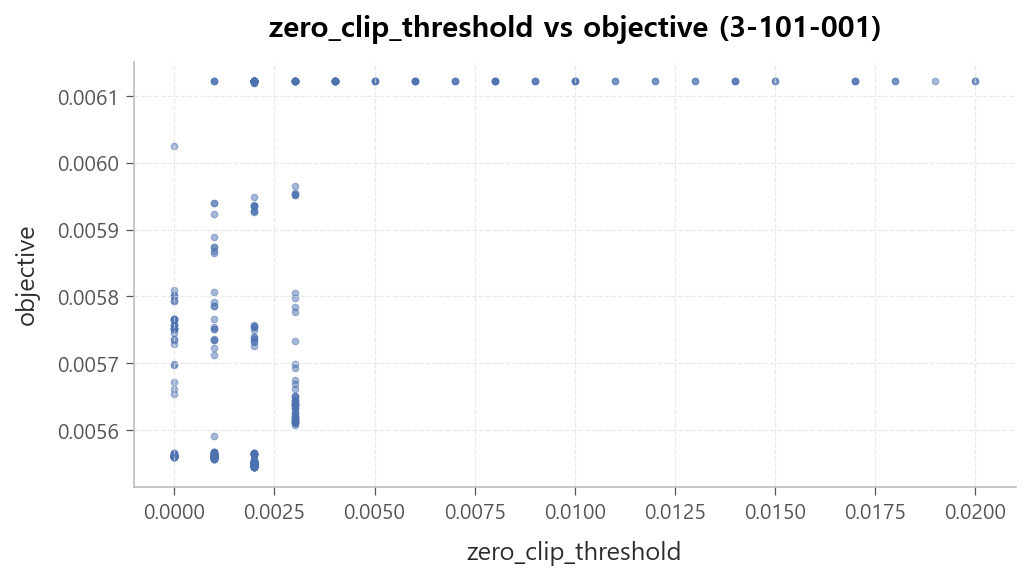

In [7]:
import matplotlib.pyplot as plt

# 보고 싶은 파라미터 — None이면 importance 1위
PARAM = "zero_clip_threshold"
if PARAM is None:
    PARAM = importance_df.iloc[0]["param"]
col = f"params_{PARAM}"
print(f"param: {PARAM}")

s = sub_sorted[[col, "value"]].dropna()

if pd.api.types.is_numeric_dtype(s[col]):
    try:
        bins = pd.qcut(s[col], q=10, duplicates="drop")
    except ValueError:
        bins = pd.cut(s[col], bins=10)
    bucket = s.groupby(bins, observed=True)["value"].agg(["count", "mean", "median", "min", "max"])
    display(bucket)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(s[col], s["value"], s=10, alpha=0.5)
    ax.set_xlabel(PARAM); ax.set_ylabel("objective")
    ax.set_title(f"{PARAM} vs objective ({TARGET_STUDY})")
    plt.tight_layout(); plt.show()
else:
    bucket = s.groupby(col, observed=True)["value"].agg(["count", "mean", "median", "min", "max"])
    bucket = bucket.sort_values("mean", ascending=ascending)
    display(bucket)